In [35]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import os

def independently_resample_eft_to_pkl(
    file_path: str,
    weight_branch: str = "final_weight",
    max_events: int = None,
    output_path: str = "picklefile/output.pkl"
):
    """
    Independently resample GEN and RECO level observables using `final_weight` as sampling probability.
    Keeps trueLevelWeight (GEN) and event_weight (RECO) untouched.
    Skips jagged (variable-length) arrays that can't be saved in a flat table.
    """
    with uproot.open(file_path) as f:
        gen_tree = f["ttBar_treeVariables_step0"]
        reco_tree = f["ttBar_treeVariables_step8"]

        gen_keys = gen_tree.keys()
        reco_keys = reco_tree.keys()

        gen_wb = weight_branch if weight_branch in gen_keys else "finalWeight"
        reco_wb = weight_branch if weight_branch in reco_keys else "finalWeight"

        # Load all branches
        gen_data = gen_tree.arrays(gen_keys, library="ak")
        reco_data = reco_tree.arrays(reco_keys, library="ak")

    # --- GEN sampling ---
    gen_weights = ak.to_numpy(gen_data[gen_wb]).clip(min=0)
    if max_events:
        gen_subset_idx = np.random.choice(len(gen_data), size=min(len(gen_data), max_events), replace=False)
        gen_data = gen_data[gen_subset_idx]
        gen_weights = gen_weights[gen_subset_idx]
    gen_weights /= gen_weights.sum()
    gen_sampled = gen_data[np.random.choice(len(gen_data), size=len(gen_data), p=gen_weights)]

    # --- RECO sampling ---
    reco_weights = ak.to_numpy(reco_data[reco_wb]).clip(min=0)
    if max_events:
        reco_subset_idx = np.random.choice(len(reco_data), size=min(len(reco_data), max_events), replace=False)
        reco_data = reco_data[reco_subset_idx]
        reco_weights = reco_weights[reco_subset_idx]
    reco_weights /= reco_weights.sum()
    reco_sampled = reco_data[np.random.choice(len(reco_data), size=len(reco_data), p=reco_weights)]

    # Convert to DataFrames (skip jagged/irregular fields)
    def flatten_awkward_to_dict(arr, skip_field):
        out = {}
        for k in arr.fields:
            if k == skip_field:
                continue
            try:
                flat = ak.to_numpy(arr[k])
                if flat.ndim == 1:
                    out[k] = flat
            except Exception:
                continue  # Skip jagged or nested branches
        return out

    gen_df = pd.DataFrame(flatten_awkward_to_dict(gen_sampled, gen_wb))
    reco_df = pd.DataFrame(flatten_awkward_to_dict(reco_sampled, reco_wb))

    output_dict = {
        "gen": gen_df,
        "reco": reco_df
    }

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    pd.to_pickle(output_dict, output_path)
    print(f"Saved GEN: {len(gen_df)} events, RECO: {len(reco_df)} events → {output_path}")
    return output_dict


In [36]:
independently_resample_eft_to_pkl(
    file_path="EFT_SM_files/EFT_ctgRe2.root",
    weight_branch="finalWeight",
    max_events=21000000,
    output_path="picklefile/sample_EFT_ctgRe2.pkl"
)

independently_resample_eft_to_pkl(
    file_path="EFT_SM_files/EFT_reweightedSM_ctgRe0.root",
    weight_branch="finalWeight",
    max_events=21000000,
    output_path="picklefile/sample_SM_ctgRe0.pkl"
)


Saved GEN: 20977851 events, RECO: 3491846 events → picklefile/sample_EFT_ctgRe2.pkl
Saved GEN: 20977851 events, RECO: 3491846 events → picklefile/sample_SM_ctgRe0.pkl


{'gen':           gen_top_pt  gen_top_phi  gen_top_rapidity  gen_top_eta  \
 0         206.647125     0.853935         -0.447511    -0.571649   
 1          99.353188     1.991022         -0.547680    -0.986505   
 2         298.818268     0.111451          1.258172     1.382810   
 3         138.687424     0.926049          0.323551     0.503123   
 4         105.385109     3.002560          0.517793     0.907179   
 ...              ...          ...               ...          ...   
 20977846  143.246582     0.942254          0.379862     0.574229   
 20977847  314.325378     2.352339          0.081383     0.092859   
 20977848   74.305290    -0.960417         -0.293198    -0.696677   
 20977849  142.079834     0.525827          0.454628     0.685403   
 20977850  201.345734     0.774874         -1.569120    -1.827473   
 
           gen_top_mass  gen_tbar_pt  gen_tbar_phi  gen_tbar_rapidity  \
 0           172.992538   135.067001     -1.744615           1.160474   
 1           172.

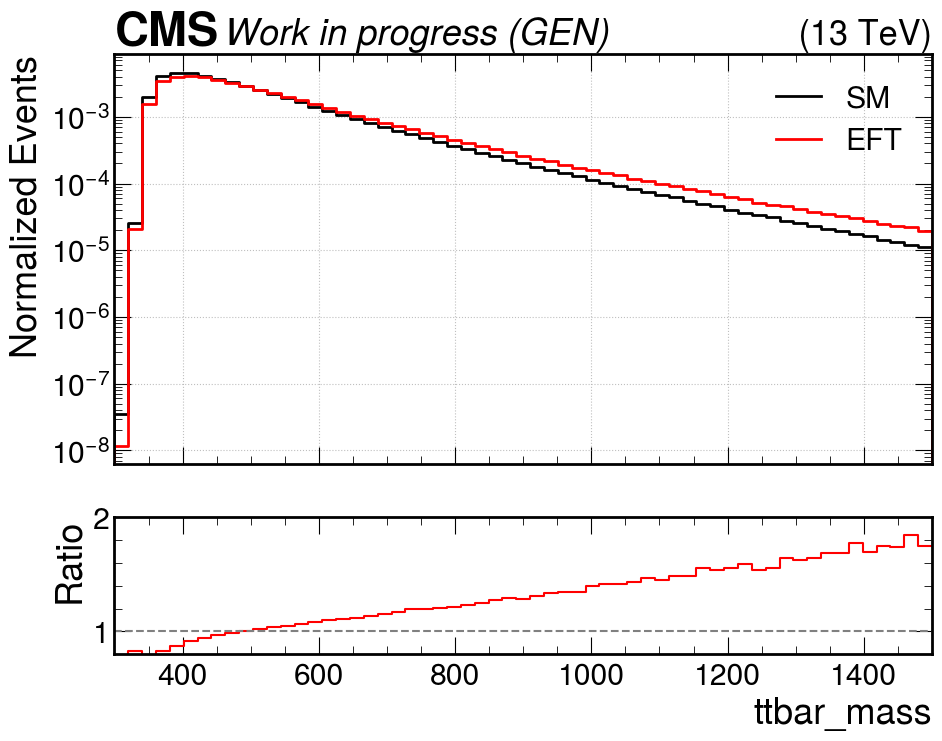

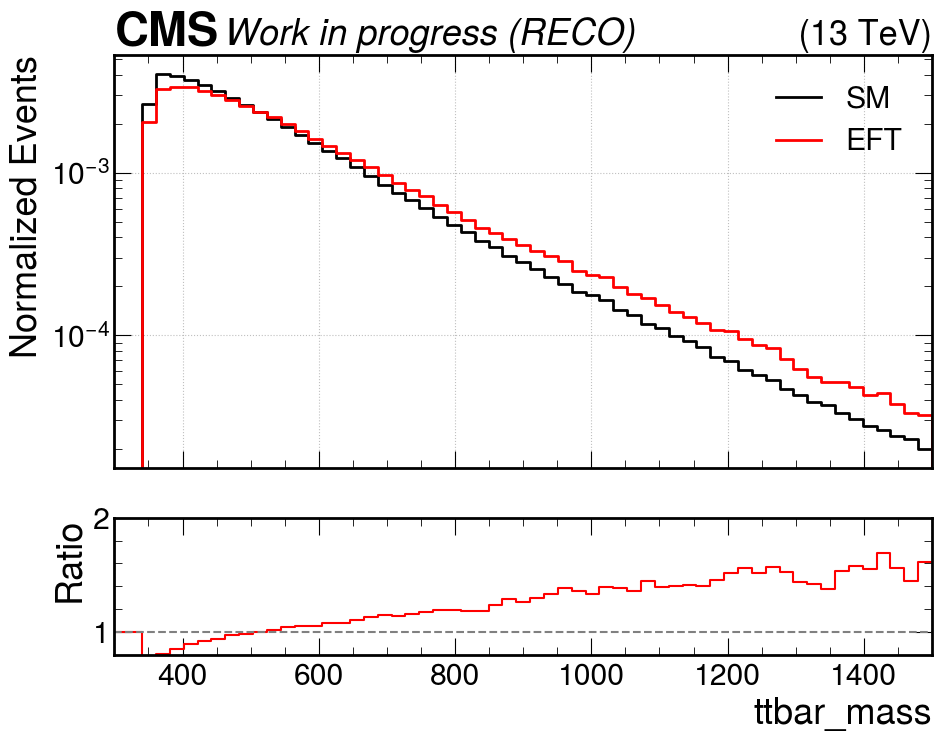

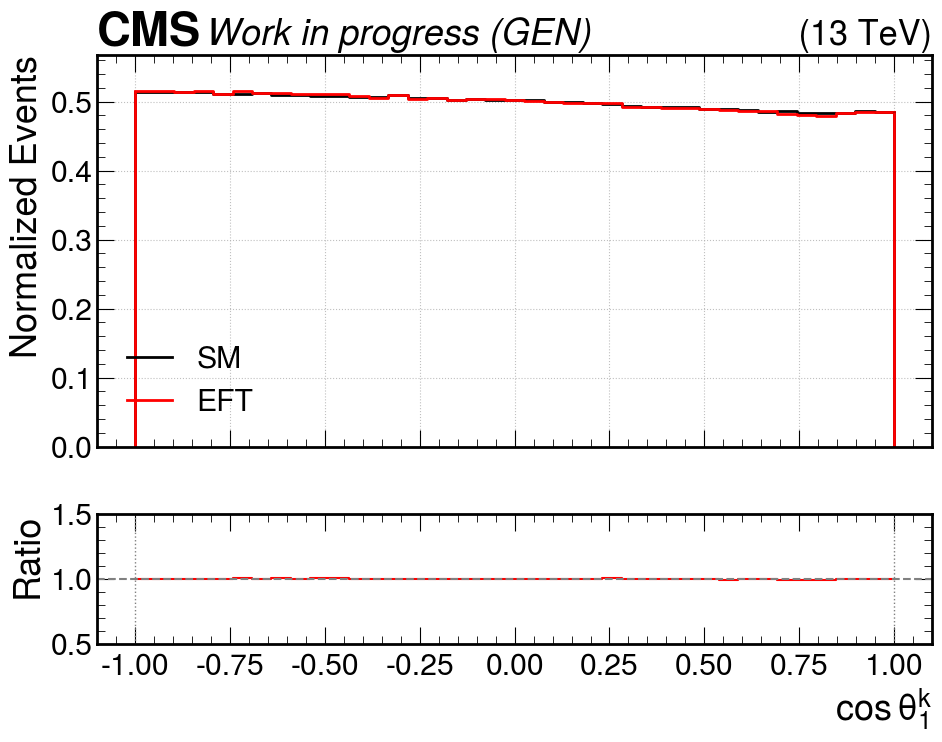

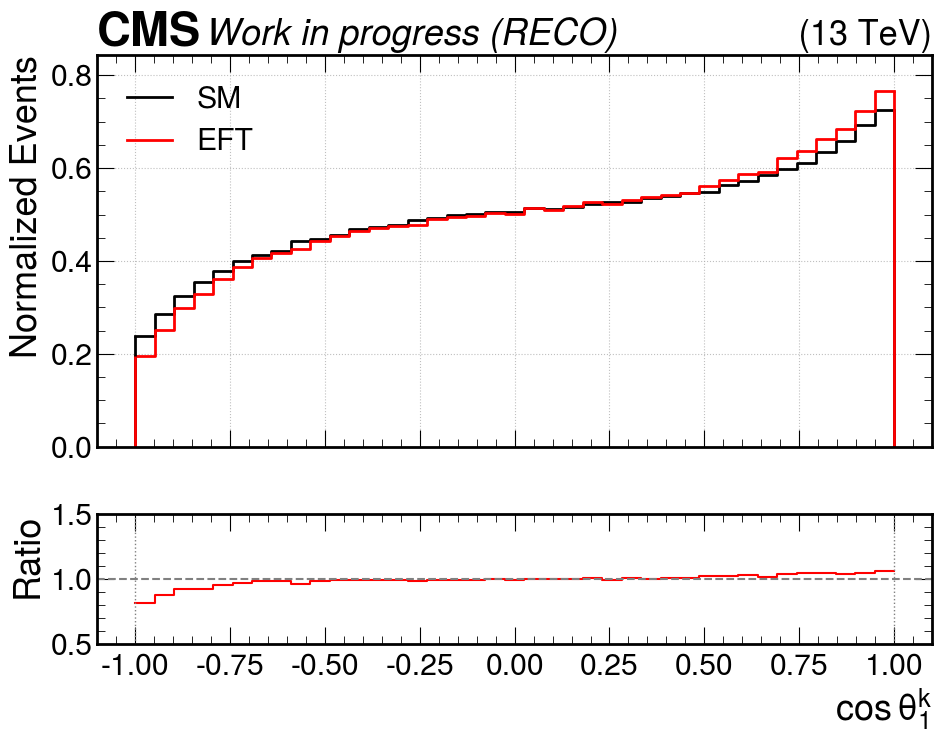

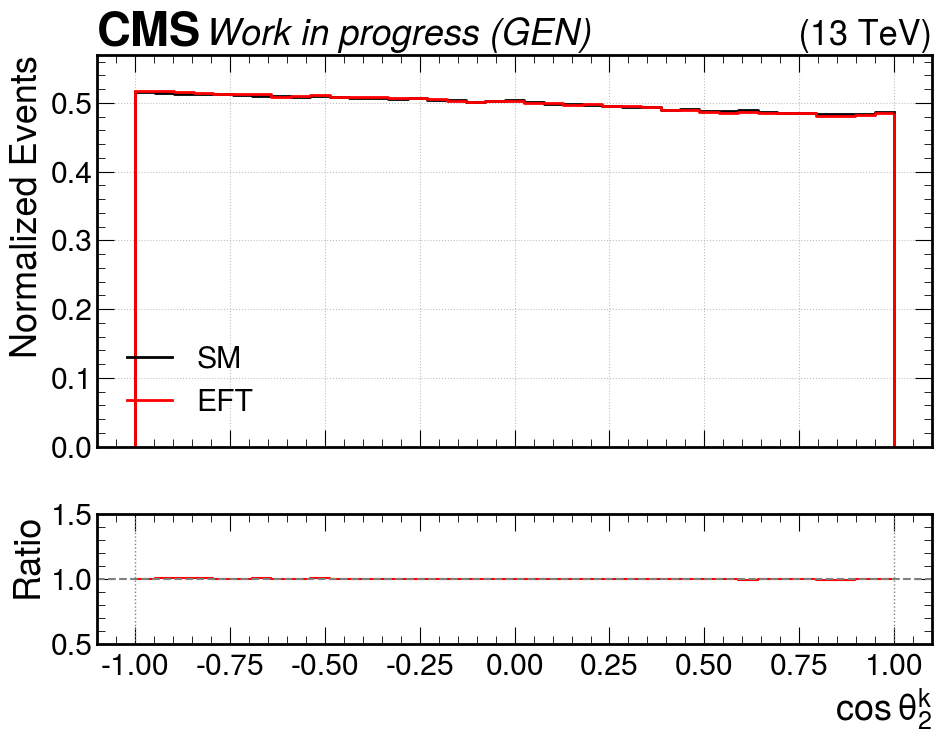

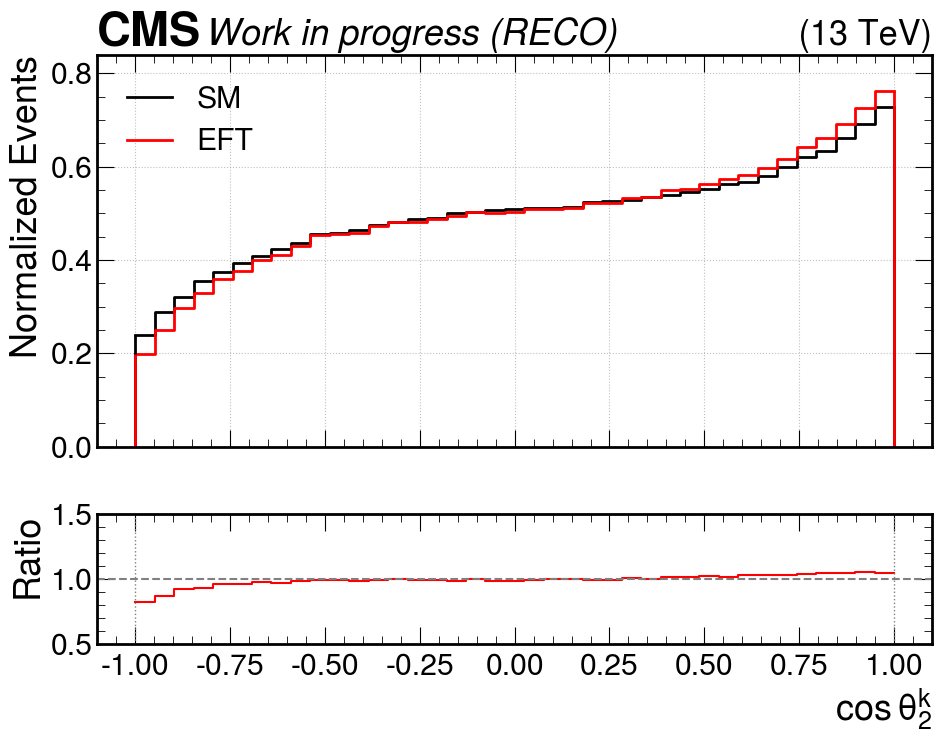

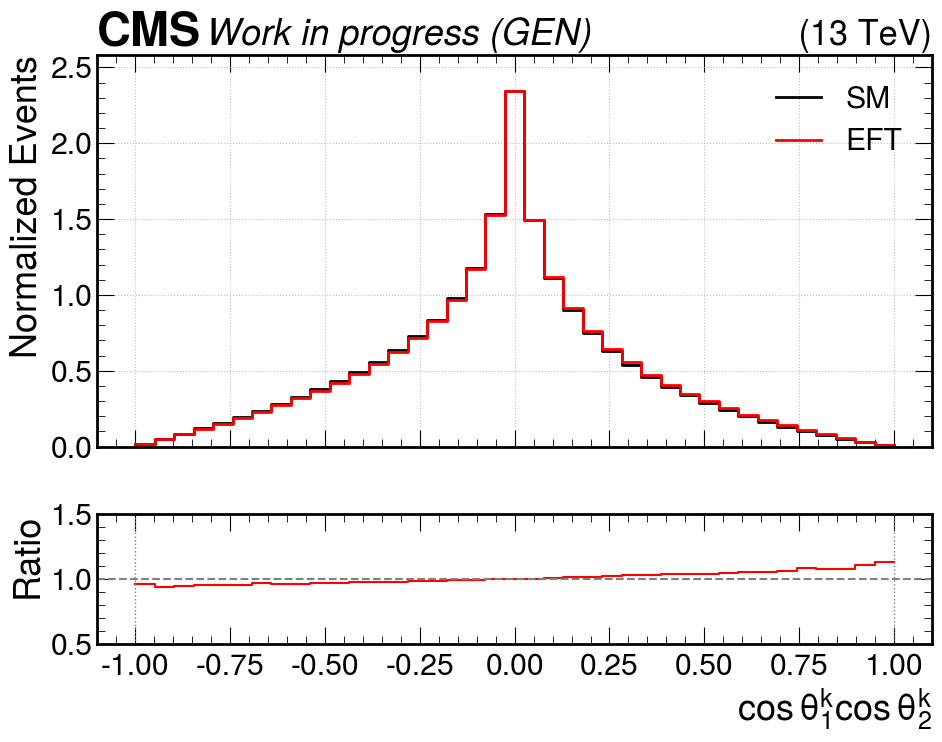

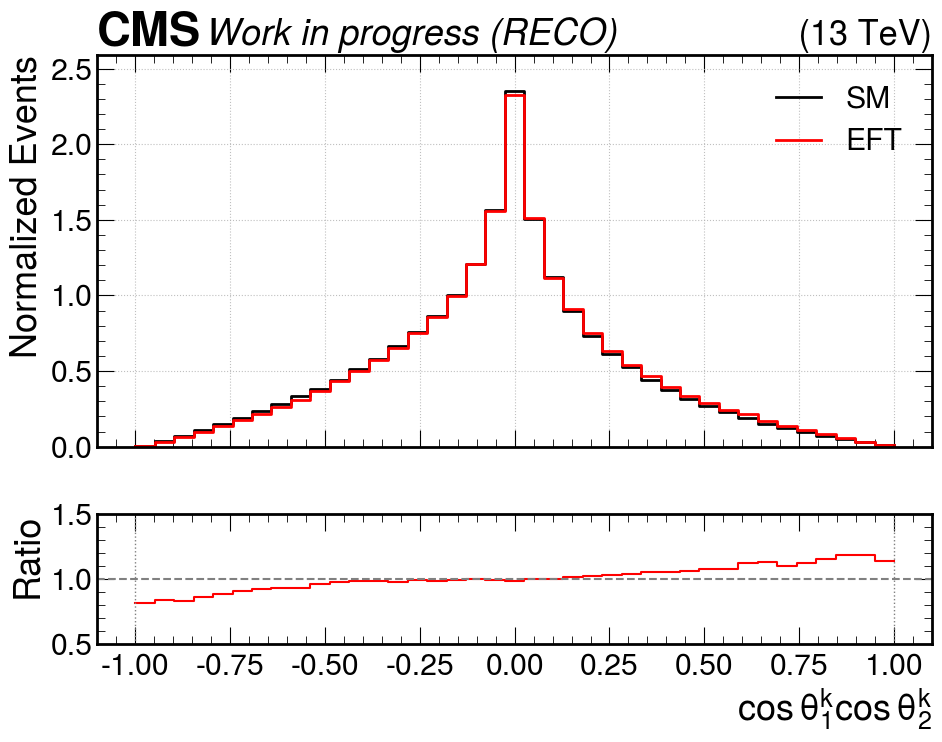

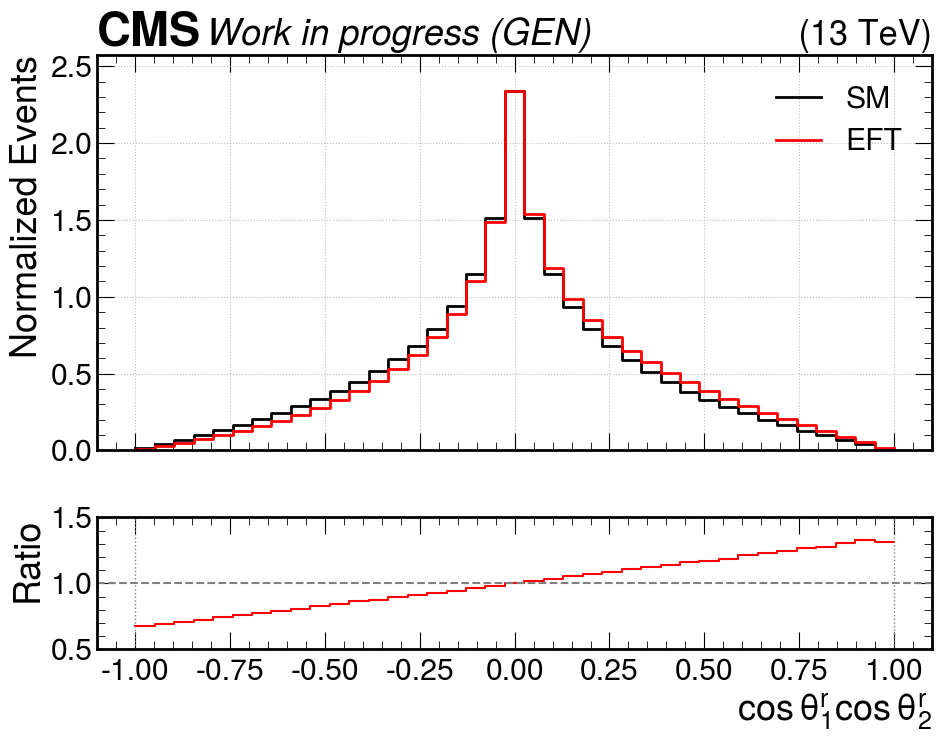

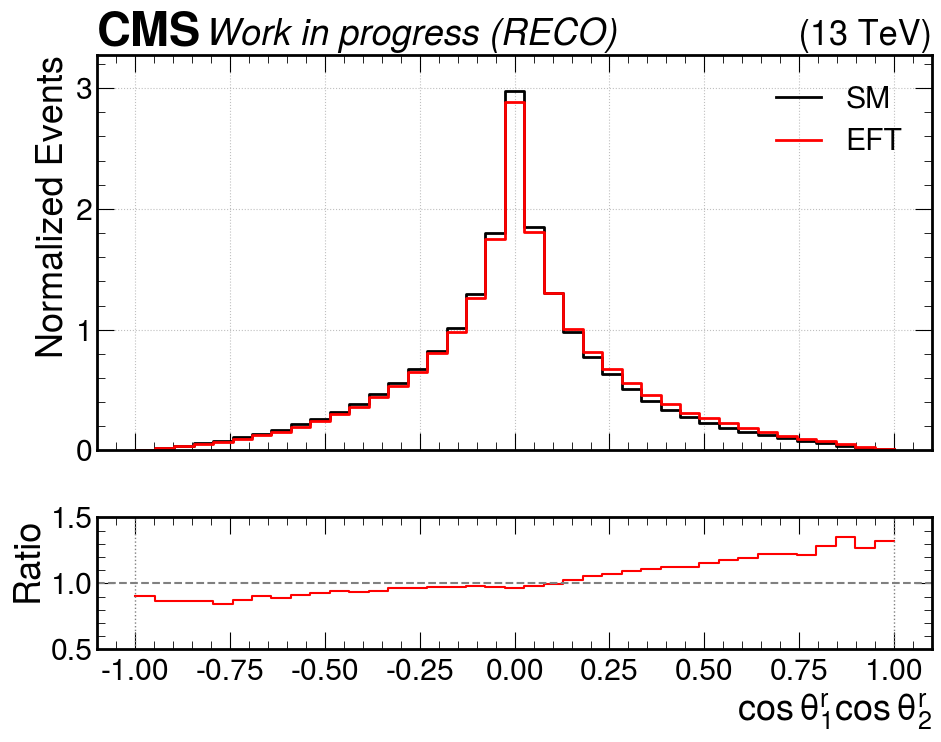

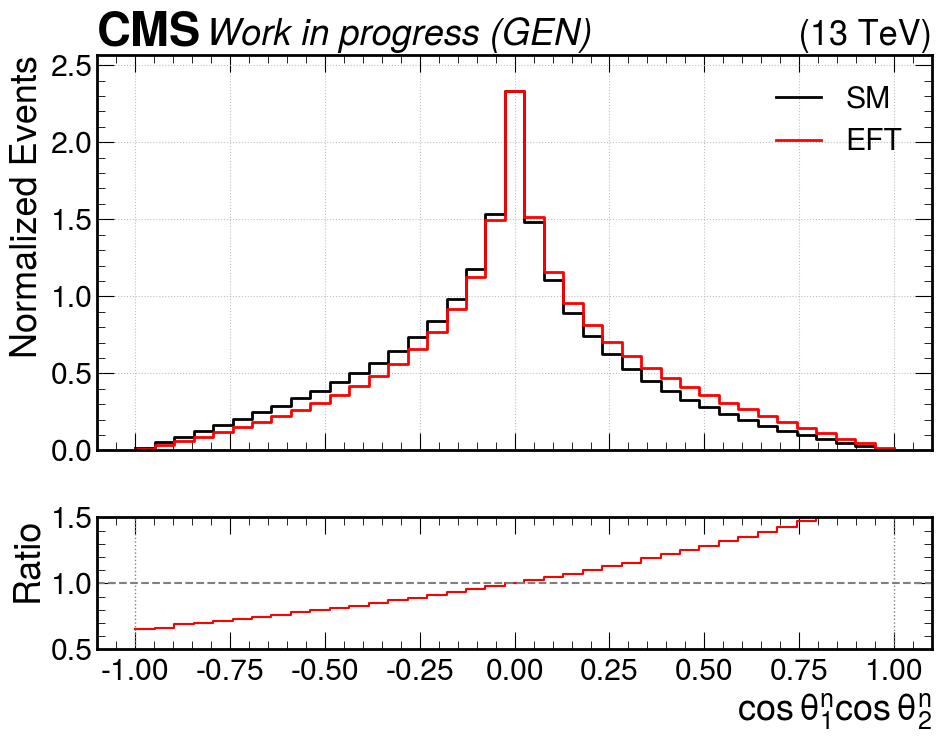

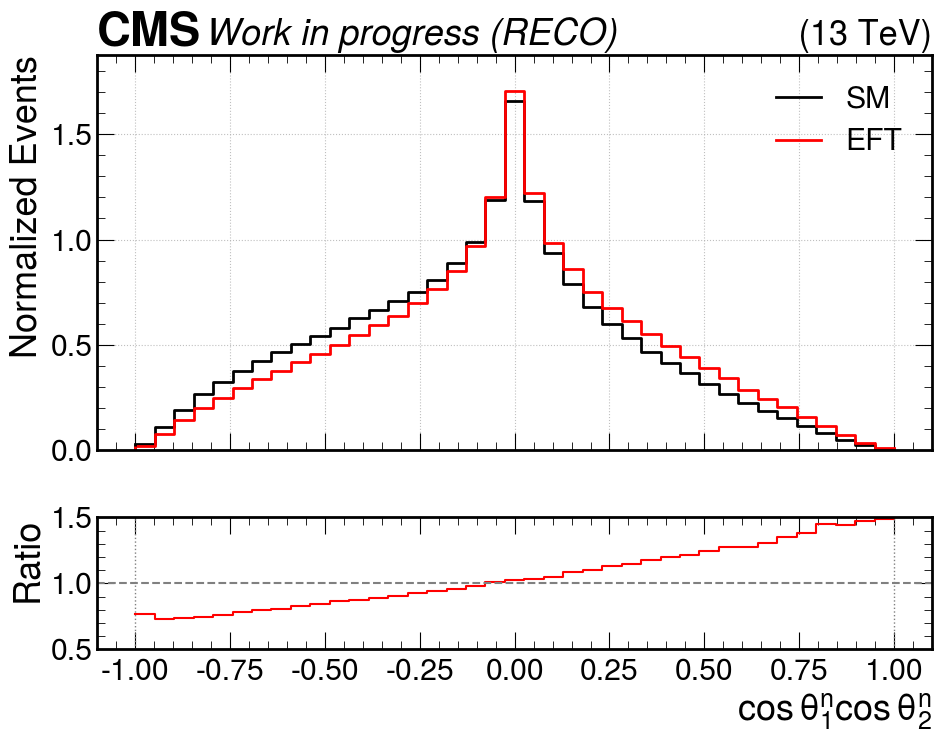

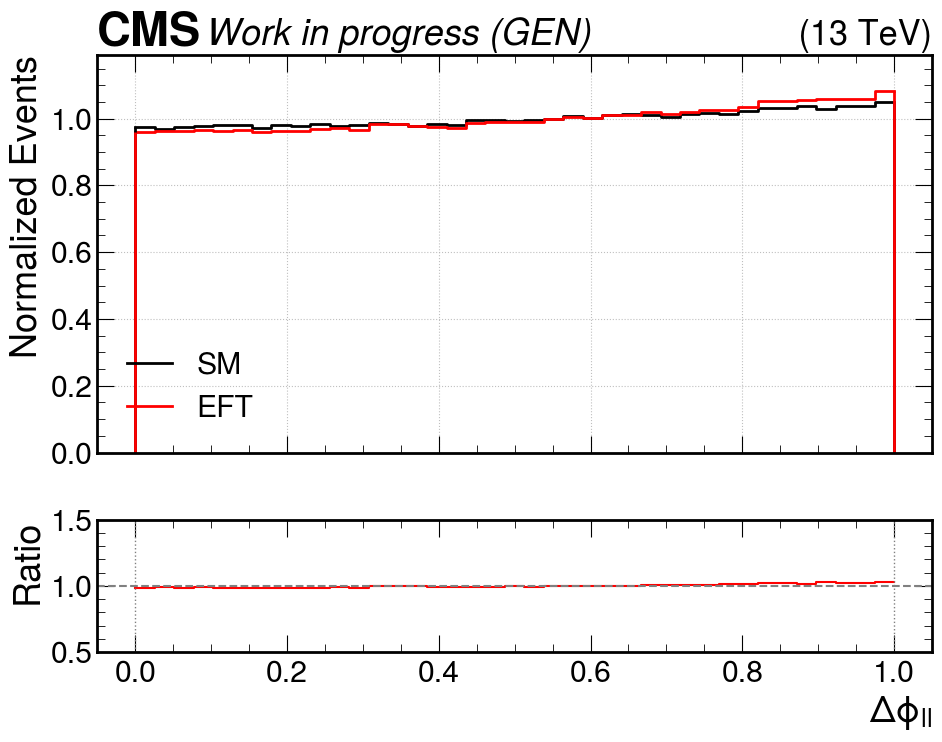

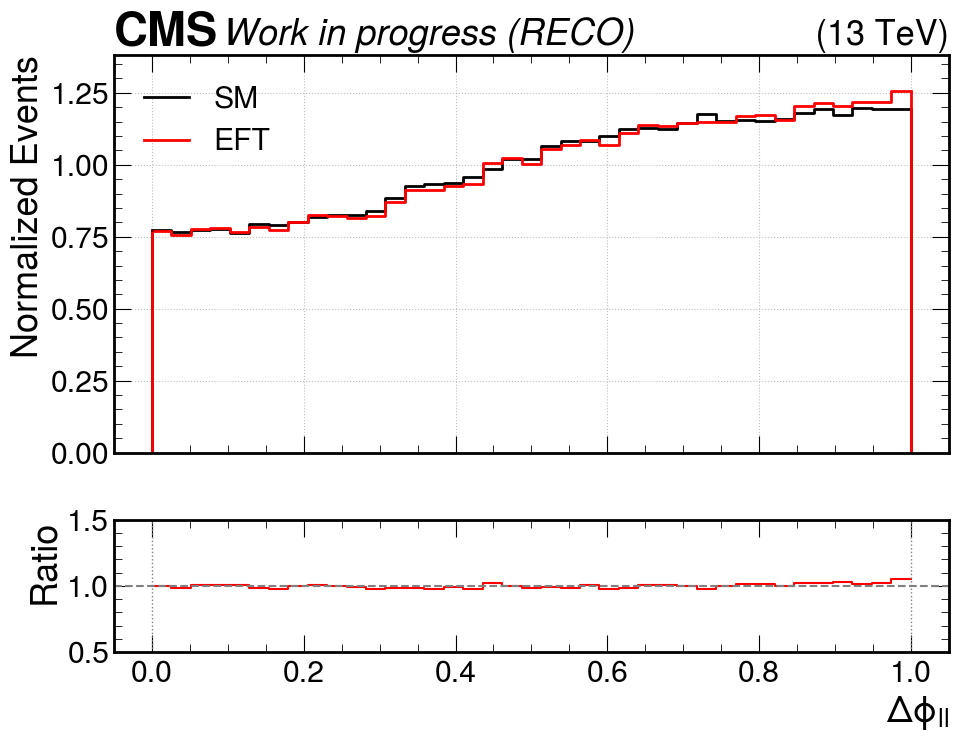

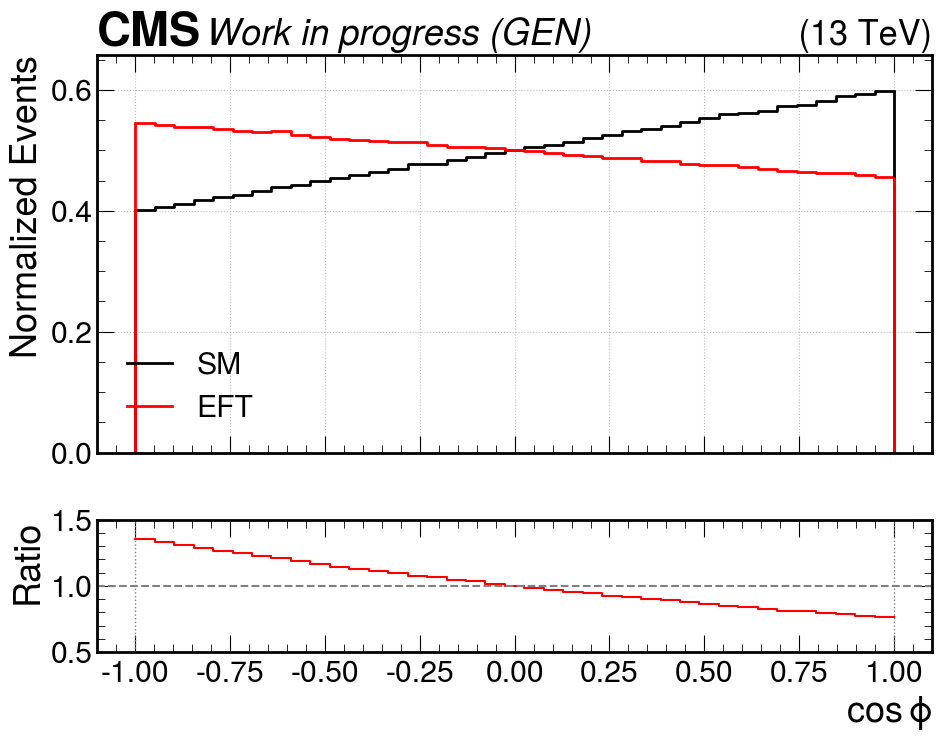

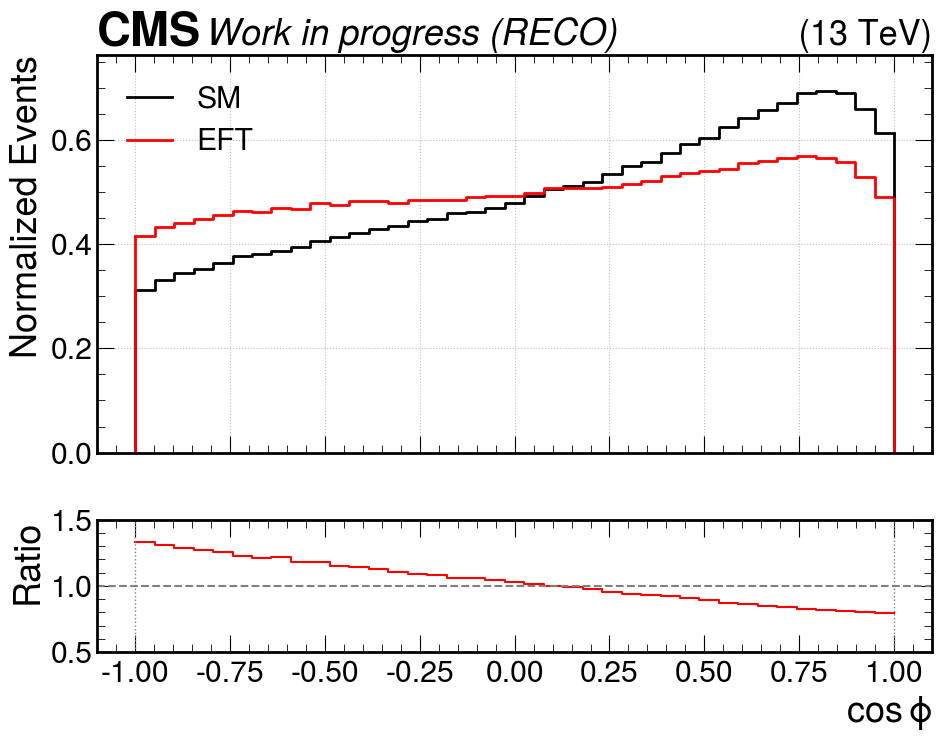

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep
mplhep.style.use("CMS")
# Load data
df_sm = pd.read_pickle("picklefile/sample_SM_ctgRe0.pkl")
df_eft = pd.read_pickle("picklefile/sample_EFT_ctgRe2.pkl")

# Observable labels and binning
observable_labels = {
    "b1k": r"$\cos\theta_1^k$", "b2k": r"$\cos\theta_2^k$",
    "b1r": r"$\cos\theta_1^r$", "b2r": r"$\cos\theta_2^r$",
    "b1n": r"$\cos\theta_1^n$", "b2n": r"$\cos\theta_2^n$",
    "c_kk": r"$\cos\theta_1^k \cos\theta_2^k$", "c_kr": r"$\cos\theta_1^k \cos\theta_2^r$", "c_kn": r"$\cos\theta_1^k \cos\theta_2^n$",
    "c_rk": r"$\cos\theta_1^r \cos\theta_2^k$", "c_rr": r"$\cos\theta_1^r \cos\theta_2^r$", "c_rn": r"$\cos\theta_1^r \cos\theta_2^n$",
    "c_nk": r"$\cos\theta_1^n \cos\theta_2^k$", "c_nr": r"$\cos\theta_1^n \cos\theta_2^r$", "c_nn": r"$\cos\theta_1^n \cos\theta_2^n$",
    "ll_cHel": r"$\cos\phi$",
    "llbar_delta_phi": r"$\Delta\phi_{ll}$",
    "top_pt": r"$p_T^\mathrm{top}$", "top_phi": r"$\phi^\mathrm{top}$",
    "top_rapidity": r"$y^\mathrm{top}$", "top_eta": r"$\eta^\mathrm{top}$",
    "ttbar_pt": r"$p_T^{t\bar{t}}$", "ttbar_phi": r"$\phi^{t\bar{t}}$",
    "ttbar_rapidity": r"$y^{t\bar{t}}$", "ttbar_eta": r"$\eta^{t\bar{t}}$",
    "ttbar_delta_phi": r"$\Delta\phi_{t\bar{t}}$", "ttbar_delta_eta": r"$\Delta\eta_{t\bar{t}}$",
    "gen_ttbar_mass": r"$m_{t\bar{t}}$"
}

binning_dict = {
    "ttbar_mass": np.linspace(300, 1500, 60),
    "b1k": np.linspace(-1, 1, 40),
    "b2k": np.linspace(-1, 1, 40),
    "c_kk": np.linspace(-1, 1, 40),
    "c_rr": np.linspace(-1, 1, 40),
    "c_nn": np.linspace(-1, 1, 40),
    "llbar_delta_phi": np.linspace(0, 1, 40),
    "ll_cHel": np.linspace(-1, 1, 40),
}

# Plot function
def plot_comparison_with_ratio(df_sm_dict, df_eft_dict, step, observable):
    import matplotlib.pyplot as plt
    import numpy as np
    import mplhep

    prefix = "gen_" if step == 0 else ""
    df_key = "gen" if step == 0 else "reco"
    observable_full = prefix + observable

    if observable_full not in df_sm_dict[df_key].columns:
        print(f"Observable '{observable_full}' not found in {df_key} data.")
        return

    data_sm = df_sm_dict[df_key][observable_full].dropna()
    data_eft = df_eft_dict[df_key][observable_full].dropna()

    bins = binning_dict.get(observable, 60)
    bin_edges = np.histogram_bin_edges(np.concatenate([data_sm, data_eft]), bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig, (ax, ax_ratio) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                       gridspec_kw={"height_ratios": [3, 1]})
    plt.subplots_adjust(hspace=0.05)

    # Histograms
    counts_sm, _ = np.histogram(data_sm, bins=bin_edges, density=True)
    counts_eft, _ = np.histogram(data_eft, bins=bin_edges, density=True)

    ax.step(bin_edges, np.append(counts_sm, counts_sm[-1]), where='post', label="SM", color='black', linewidth=2)
    ax.step(bin_edges, np.append(counts_eft, counts_eft[-1]), where='post', label="EFT", color='red', linewidth=2)

    # Vertical edge lines for SM and EFT (optional but clearer for step histograms)
    ax.vlines([bin_edges[0], bin_edges[-1]], ymin=0, ymax=[counts_sm[0], counts_sm[-1]],
              color='black', linewidth=2)
    ax.vlines([bin_edges[0], bin_edges[-1]], ymin=0, ymax=[counts_eft[0], counts_eft[-1]],
              color='red', linewidth=2)

    ax.set_ylabel("Normalized Events")
    ax.legend()
    ax.grid(True)

    if observable == "ttbar_mass":
        ax.set_yscale("log")
        ax.set_xlim(300, 1500)
        ax_ratio.set_xlim(300, 1500)
        ax_ratio.set_ylim(0.8, 2)
    else:
        ax.set_ylim(0, 1.1 * max(np.max(counts_sm), np.max(counts_eft)))
        ax_ratio.set_ylim(0.5, 1.5)

    # Ratio plot
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.divide(counts_eft, counts_sm, out=np.ones_like(counts_eft), where=counts_sm != 0)

    ax_ratio.step(bin_edges, np.append(ratio, ratio[-1]), where='post', color='red')
    ax_ratio.axhline(1, color='gray', linestyle='--')
    ax_ratio.set_ylabel("Ratio")
    ax_ratio.set_xlabel(observable_labels.get(observable, observable))

    # Edge lines on ratio plot too
    ax_ratio.vlines([bin_edges[0], bin_edges[-1]], ymin=ax_ratio.get_ylim()[0], ymax=ax_ratio.get_ylim()[1],
                    color='gray', linestyle=':', linewidth=1)

    # CMS label
    label_text = "GEN" if step == 0 else "RECO"
    mplhep.cms.label(f"Work in progress ({label_text})", data=True, ax=ax, loc=0)

    plt.tight_layout()
    plt.show()


# Plot each observable for both GEN and RECO
for obs in binning_dict.keys():
    plot_comparison_with_ratio(df_sm, df_eft, step=0, observable=obs)
    plot_comparison_with_ratio(df_sm, df_eft, step=8, observable=obs)
